In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
%matplotlib inline

In [2]:
import requests
def download_file(url, file_name): 
    response = requests.get(url)
    if response.status_code == 200 : 
        with open(file_name, "wb") as f : 
            f.write(response.content)
            print("File successfully written")

In [6]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv"

In [7]:
download_file(file_path, "teleCust1000t.csv")
file_name = "teleCust1000t.csv"


File successfully written


In [8]:
df = pd.read_csv(file_name)
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


In [9]:
df["custcat"].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

<Axes: >

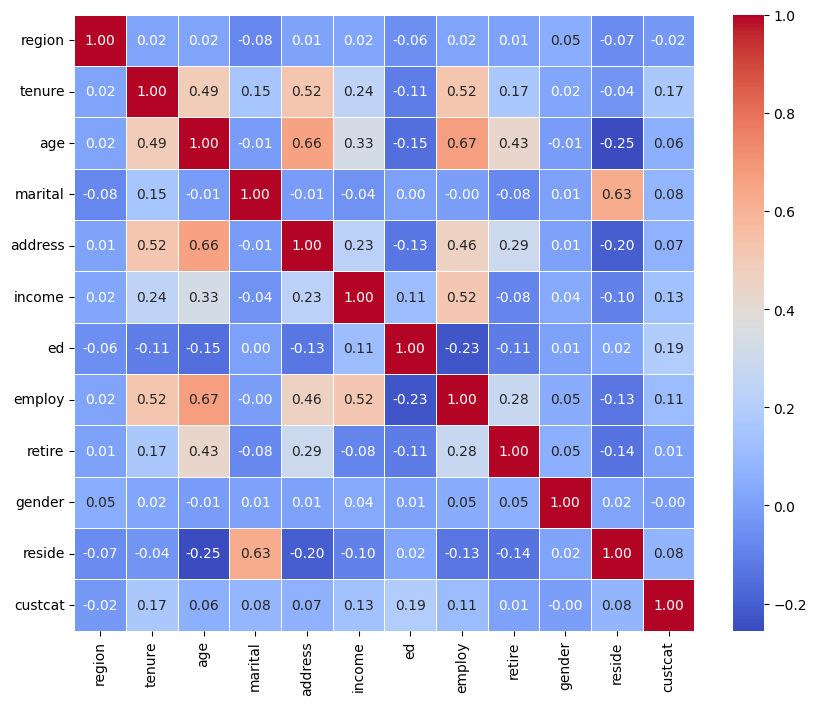

In [10]:
correlation_matrix = df.corr() 
plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot = True, cmap = "coolwarm" , fmt= ".2f", linewidths = 0.5)

In [11]:
correlation_values = abs(df.corr()['custcat'].drop('custcat')).sort_values(ascending=False)
correlation_values

ed         0.193864
tenure     0.166691
income     0.134525
employ     0.110011
marital    0.083836
reside     0.082022
address    0.067913
age        0.056909
region     0.023771
retire     0.008908
gender     0.004966
Name: custcat, dtype: float64

In [13]:
X = df.drop(["custcat"], axis = 1)
y = df["custcat"]
X.dtypes

region       int64
tenure       int64
age          int64
marital      int64
address      int64
income     float64
ed           int64
employ       int64
retire     float64
gender       int64
reside       int64
dtype: object

In [14]:
X_norm = StandardScaler().fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size = 0.2, random_state = 42)

In [21]:
k = 3
#Train model using knn
knn_classifier = KNeighborsClassifier(n_neighbors = k)
knn_model = knn_classifier.fit(X_train, y_train)

In [23]:
yhat = knn_model.predict(X_test)

In [24]:
print("Test set accuracy :", accuracy_score(y_test, yhat))

Test set accuracy : 0.365


In [25]:
#Can you build the model again, but this time with k=6?
k = 6  
knn_classifier = KNeighborsClassifier(n_neighbors = 6) 
knn_model = knn_classifier.fit(X_train, y_train)

In [28]:
yhat = knn_model.predict(X_test)

In [29]:
print("Test set accuracy score is :", accuracy_score(y_test, yhat))

Test set accuracy score is : 0.33


In [30]:
#Choosing correct value of k 
Ks = 10 
acc = np.zeros((Ks))
std_acc = np.zeros((Ks))
for n in range(1, Ks+1): 
    #Train model and predict
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(X_train, y_train)
    yhat = knn_model_n.predict(X_test)
    acc[n-1] = accuracy_score(y_test, yhat)
    std_acc[n-1] = np.std(yhat == y_test)/np.sqrt(yhat.shape[0])

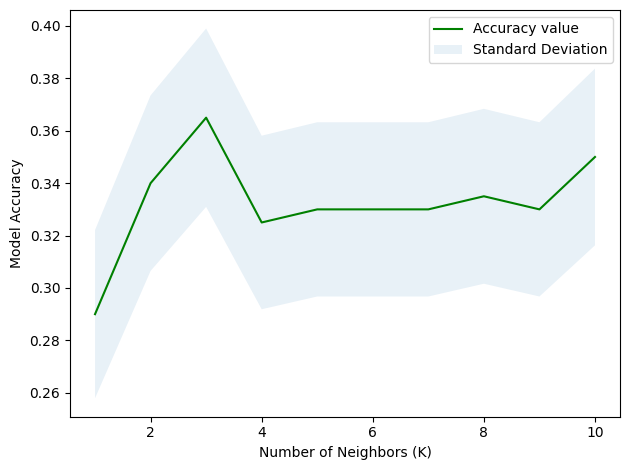

In [31]:
plt.plot(range(1,Ks+1),acc,'g')
plt.fill_between(range(1,Ks+1),acc - 1 * std_acc,acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

In [32]:
print( "The best accuracy was with", acc.max(), "with k =", acc.argmax()+1) 

The best accuracy was with 0.365 with k = 3
